In [1]:
import os
import cv2
import time
import json
import yaml
import torch
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

from utils.sdf import SDF
from configs.cfgparser import Config

# Enable if you have libiomp5md.dll conflicts (not a permanent fix)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [41]:
with Path("./configs/config.yaml").open() as f:
    cfg: dict = yaml.load(f, Loader=yaml.FullLoader)
CONF: Config = Config(cfg)

KSIZES: list[int] = [3, 5, 7, 9, 11, 13, 15]

[INFO] Configuration file passed all validation tests.
[WARN]: Experiment directory 'saved\baseline' contains files matching RUN_ID 'UNet_SoftDICE(boundary)'; they will be overwritten.


### Kernel Size Test

PyTorch/cuDNN pick different convolution algorithms depending on kernel size and tensor shapes. Around 7–11, cuDNN often flips from “direct/Winograd” (good for very small kernels) to FFT/implicit-GEMM (better for larger kernels). That switch can dwarf the usual “bigger K = slower” intuition - especially when your outer loop also needs fewer iterations as K grows (which is exactly the case for our SDM algorithm). This test should help you choose the optimal **CONF.SDM_KERNEL_SIZE** that works best for your dataset. Just select the smallest kernel size at which the performance curve begins to flatten.

In [42]:
# Either use defaults from config.yaml or set manually
imsize: int = CONF.INPUT_SIZE
batch: int = CONF.BATCH_SIZE
n_iters: int = 1000
# ----------------------------------------------------

# demo masks for quick & consistent testing
mask_tensor = torch.tril(torch.ones((imsize, imsize), device='cuda:0'))
mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)
mask_tensor_batch = mask_tensor.repeat(batch, 1, 1, 1)

kernel_size_test: list[float] = []
for k in KSIZES:

    t1 = time.time()
    for i in tqdm(range(n_iters // batch), desc=f"K {k}"):
        SDF.sdf(mask_tensor_batch, K=k, distance='chebyshev', normalization=None)

    t2 = time.time()
    dt = t2 - t1
    kernel_size_test.append(dt)

K 15: 100%|██████████| 62/62 [00:02<00:00, 29.54it/s]


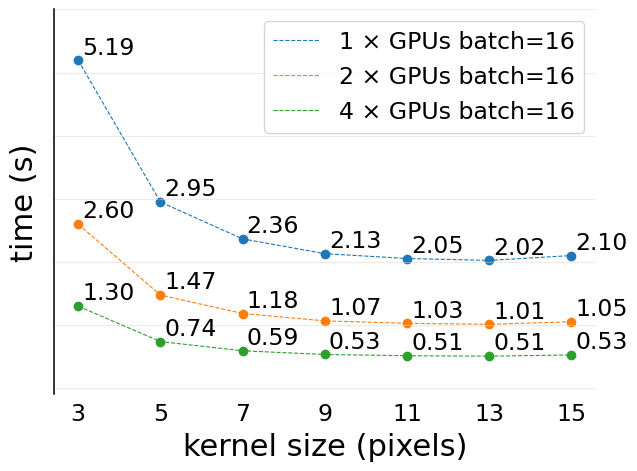

In [43]:
fig, ax = plt.subplots(figsize=(7,5)) 

def plot_ksize_test(arr: list[float], ax):
    """Plot kernel size test results for different GPU counts.

    Args:
        arr: List of timing results for each kernel size (seconds).
        ax: Matplotlib Axes object to plot on.

    """
    y = np.array(arr)

    for gpu in [1,2,4]:
        ax.scatter(KSIZES, y/gpu)
        ax.plot(KSIZES, y/gpu, linestyle='--', linewidth = 0.8, label= f'{gpu} \u00d7 GPUs batch=16')

        for i in range(len(KSIZES)):
            ax.text(KSIZES[i] + 0.1, 
                y[i]/gpu + 0.1, 
                f'{y[i]/gpu:.2f}', fontsize=17)
            
    ax.grid(which="major", axis='y', color='#DAD8D7', alpha=0.5, zorder=1)
    ax.spines[['top','right', 'bottom']].set_visible(False)
    ax.spines['left'].set_linewidth(1.1)

    ax.set_ylim(-0.1,6)
    ax.set_xticks(ticks=KSIZES)
    ax.set_yticklabels([])
    
    ax.yaxis.set_tick_params(pad=2, bottom=False, labelsize=17)
    ax.xaxis.set_tick_params(pad=2, bottom=False, labelsize=17)

    ax.set_ylabel('time (s)', fontsize=22, labelpad=5)
    ax.set_xlabel('kernel size (pixels)', fontsize=22, labelpad=5)

    ax.legend(fontsize=17)
    
    # save the figure and set resolution
    fig.savefig("C:/Users/Oleksii/Desktop/pHD/Thesis/Figures/sdm_results/ksize_speed.png", bbox_inches='tight', dpi=300)

plot_ksize_test(kernel_size_test, ax)

### Precision test

Here we test on real images from your dataset to make sure that our estimate does not deviate too much from the SciPy benchmark. Typically, the change in MAE across kernel sizes is negligible and does not constrain the choice of kernel size.

In [10]:
with open(CONF.LBL_JSON) as f:
    lblDict = json.load(f)
    imIDs = lblDict['label_to_id'][str(CONF.SEG_CLASSES)]

imsize: int = CONF.INPUT_SIZE
n_samples: int = 500
imIDs = imIDs[:n_samples]

total_mae = []
for imID in tqdm(imIDs):
    img_mae = []
    mask = cv2.imread(f'{CONF.MSK_DIR}/{imID}.png', cv2.IMREAD_GRAYSCALE)
    # centercrop mask to imsize x imsize
    h, w = mask.shape
    startx = w//2 - (imsize//2)
    starty = h//2 - (imsize//2)
    mask = mask[starty:starty+imsize, startx:startx+imsize]
    mask = mask > 0  # binary mask
    
    edges = cv2.Canny((255*mask).astype(np.uint8), threshold1=128, threshold2=128)
    
    sdm_scipy = distance_transform_edt(~edges)
    sdm_scipy = sdm_scipy/sdm_scipy.max()

    for k in KSIZES:
        mask_tensor = torch.tensor(mask).to(torch.float32).to('cuda:0').unsqueeze(0).unsqueeze(0)
        sdm_torch = SDF.sdf(mask_tensor, K=k, distance='chebyshev', normalization=None)
        sdm_torch = sdm_torch[0][0].detach().cpu().numpy()
        sdm_torch = sdm_torch/sdm_torch.max()

        mae = np.round(np.mean(np.abs(sdm_scipy - sdm_torch)), 3)
        img_mae.append(mae)
    total_mae.append(img_mae)

mae = [np.mean(list(x)) for x in zip(*total_mae)]

100%|██████████| 500/500 [01:32<00:00,  5.41it/s]


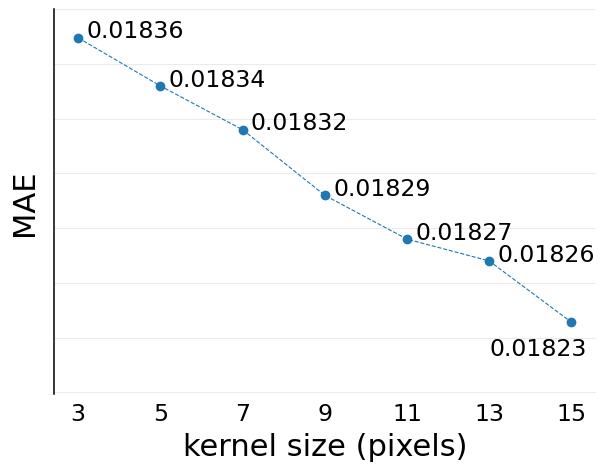

In [27]:
fig, ax = plt.subplots(figsize=(7,5))

def plot_mae(yarr, ax):
    y = np.array(yarr)

    ax.scatter(KSIZES,y)
    ax.plot(KSIZES, y, linestyle='--', linewidth = 0.8)

    for i in range(len(KSIZES) - 1):
        ax.text(KSIZES[i] + 0.2, 
                y[i], 
                f'{y[i]:.5f}', fontsize=17)
    ax.text(KSIZES[-1] - 2, y[-1] - 0.000015, f'{y[-1]:.5f}', fontsize=17)


    ax.set_ylim(.018199,.018375)

    ax.set_xticks(ticks=KSIZES)
    ax.set_yticklabels([])

    ax.grid(which="major", axis='y', color='#DAD8D7', alpha=0.5, zorder=1)

    ax.spines[['top','right', 'bottom']].set_visible(False)
    ax.spines['left'].set_linewidth(1.1)

    ax.yaxis.set_tick_params(pad=2, bottom=False, labelsize=17)
    ax.xaxis.set_tick_params(pad=2, bottom=False, labelsize=17)

    ax.set_ylabel('MAE', fontsize=22, labelpad=5)
    ax.set_xlabel('kernel size (pixels)',fontsize=22, labelpad=5)
    
plot_mae(mae, ax)
fig.savefig("C:/Users/Oleksii/Desktop/pHD/Thesis/Figures/sdm_results/ksize_mae.png", bbox_inches='tight', dpi=300)

### Speed Test

In [28]:
# Use defaults or choose custom
imsize: int = CONF.INPUT_SIZE
batch: int = CONF.BATCH_SIZE
n_iters: int = 1000
ksize: int = 11 # should be set to the best experimental value from Kernel Size Test

method_speed_test: list[tuple[str, float]] = []

# demo masks for quick & consistent testing
mask = np.zeros((imsize, imsize), dtype=np.float32) 
mask[np.tril_indices(imsize)] = 1.0
mask_tensor_cpu = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)
mask_tensor_gpu = mask_tensor_cpu.to('cuda:0')

In [29]:
# SciPy -------------------------------------------------------------------------------------------------
t1 = time.time()
for i in tqdm(range(n_iters)):
    edges = cv2.Canny((255*mask).astype(np.uint8), threshold1=128, threshold2=128)
    distance_transform_edt(~edges)

t2 = time.time()
dt = t2 - t1
method_speed_test.append(('SciPy', np.round(dt, 2)))
print(f'SciPy: {dt}s')

# PyTorch CPU ------------------------------------------------------------------------------------------
t1 = time.time()

for i in tqdm(range(n_iters)):
    SDF.sdf(mask_tensor_cpu, K=7, distance='chebyshev', normalization=None) # K=7 for CPU (faster)

t2 = time.time()
dt = t2 - t1
method_speed_test.append(('CPU', np.round(dt, 2)))
print(f'PyTorch CPU: {dt}s')

# PyTorch CPU-16 ----------------------------------------------------------------------------------------
t1 = time.time()
batched_tensor = mask_tensor_cpu.repeat(batch, 1, 1, 1)
for i in tqdm(range(n_iters // batch)):
    SDF.sdf(batched_tensor, K=7, distance='chebyshev', normalization=None) # K=7 for CPU (faster)

t2 = time.time()
dt = t2 - t1
method_speed_test.append(('CPU-16', np.round(dt, 2)))
print(f'PyTorch CPU-16: {dt}s')

# PyTorch GPU --------------------------------------------------------------------------------------------
t1 = time.time()
for i in tqdm(range(n_iters)):
    SDF.sdf(mask_tensor_gpu, K=ksize, distance='chebyshev', normalization=None)

t2 = time.time()
dt = t2 - t1
method_speed_test.append(('GPU', np.round(dt, 2)))
print(f'PyTorch GPU: {dt}s')

# PyTorch GPU-16 ------------------------------------------------------------------------------------------
t1 = time.time()
batched_tensor = mask_tensor_gpu.repeat(batch, 1, 1, 1)
for i in tqdm(range(n_iters // batch)):
    SDF.sdf(batched_tensor, K=ksize, distance='chebyshev', normalization=None)

t2 = time.time()
dt = t2 - t1
method_speed_test.append(('GPU-16', np.round(dt, 2)))
print(f'PyTorch GPU-16: {dt}s')

# PyTorch 4xGPU-16 -----------------------------------------------------------------------------------------
# This is a rough estimate that assumes perfect parallelism
method_speed_test.append(('4xGPU-16', np.round(method_speed_test[-1][-1]/4, 1)))
print(f'PyTorch 4xGPU-16: {dt}s')

100%|██████████| 1000/1000 [00:09<00:00, 109.53it/s]


SciPy: 9.130935668945312s


100%|██████████| 1000/1000 [02:19<00:00,  7.16it/s]


PyTorch CPU: 139.64908123016357s


100%|██████████| 62/62 [01:27<00:00,  1.41s/it]


PyTorch CPU-16: 87.54416418075562s


100%|██████████| 1000/1000 [00:08<00:00, 114.07it/s]


PyTorch GPU: 8.768577575683594s


100%|██████████| 62/62 [00:02<00:00, 30.67it/s]

PyTorch GPU-16: 2.023444890975952s
PyTorch 4xGPU-16: 2.023444890975952s


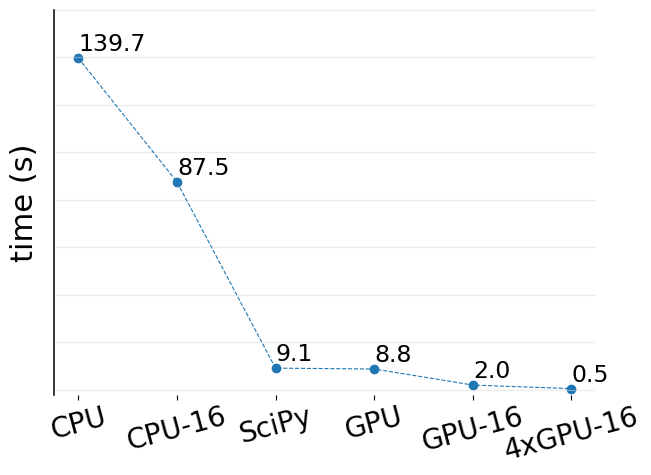

In [35]:
fig, ax = plt.subplots(figsize=(7,5))

def plot_speed_test(ax, arr):
    arr = sorted(arr, key=lambda x: x[1], reverse=True)

    x = [item[0] for item in arr]
    y = [item[1] for item in arr]
    x_i = list(range(len(x)))

    ax.scatter(x,y)
    ax.plot(x, y, linestyle='--', linewidth = 0.8)

    for i in range(len(x)):
        ax.text(x_i[i], y[i] + 3, f'{y[i]:.1f}', fontsize=17)

    ax.set_ylim(-2, 160)
    # ax.set_xlim(2, 12)
    ax.set_yticklabels([])

    ax.grid(which="major", axis='y', color='#DAD8D7', alpha=0.5, zorder=1)

    ax.spines[['top','right', 'bottom']].set_visible(False)
    ax.spines['left'].set_linewidth(1.1)

    ax.yaxis.set_tick_params(pad=2, labeltop=False, labelbottom=True, bottom=False, labelsize=15)
    ax.xaxis.set_tick_params(pad=2, labelsize=20, labelrotation=15)

    ax.set_ylabel('time (s)', fontsize=22, labelpad=5)
    
    
plot_speed_test(ax, method_speed_test)
fig.savefig("C:/Users/Oleksii/Desktop/pHD/Thesis/Figures/sdm_results/device_speed.png", bbox_inches='tight', dpi=300)

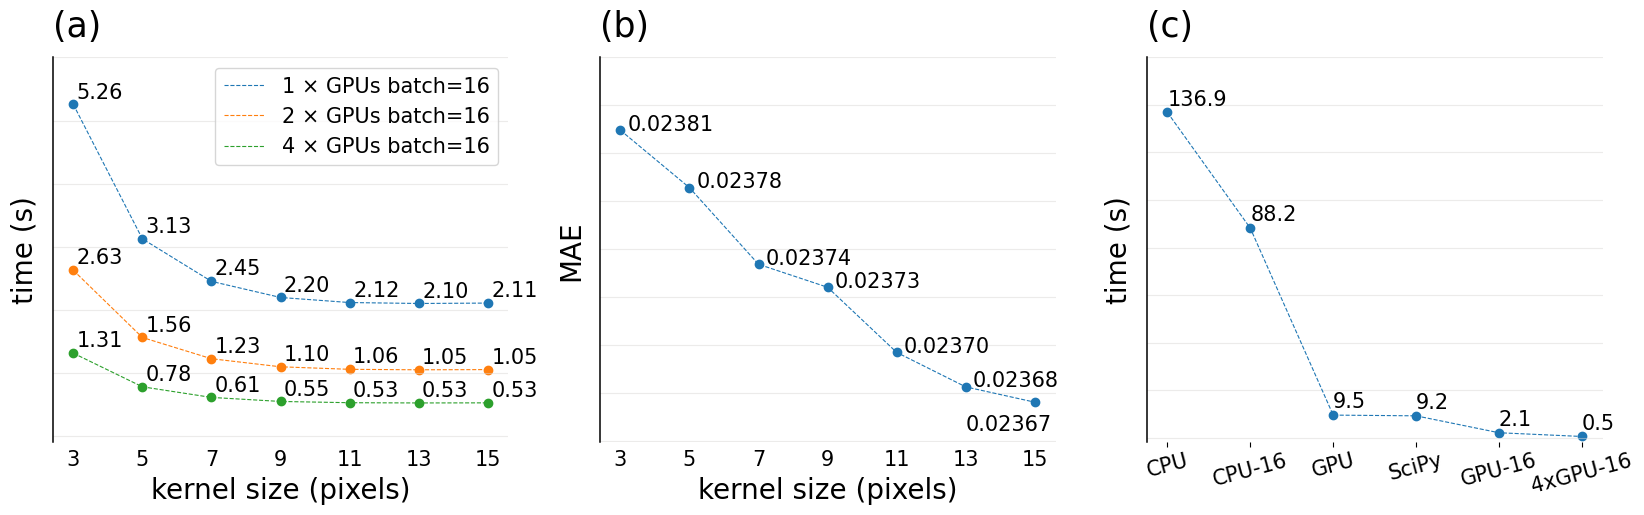

In [36]:
fig, ax = plt.subplots(1,3, figsize=(20,5))
plot_ksize_test(kernel_size_test, ax[0])
plot_mae(mae, ax[1])
plot_speed_test(ax[2], method_speed_test)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2)
plt.savefig("fig1.png", format="png", bbox_inches="tight", dpi = 250)

### Visual test

100%|██████████| 10/10 [00:00<00:00, 12.02it/s]


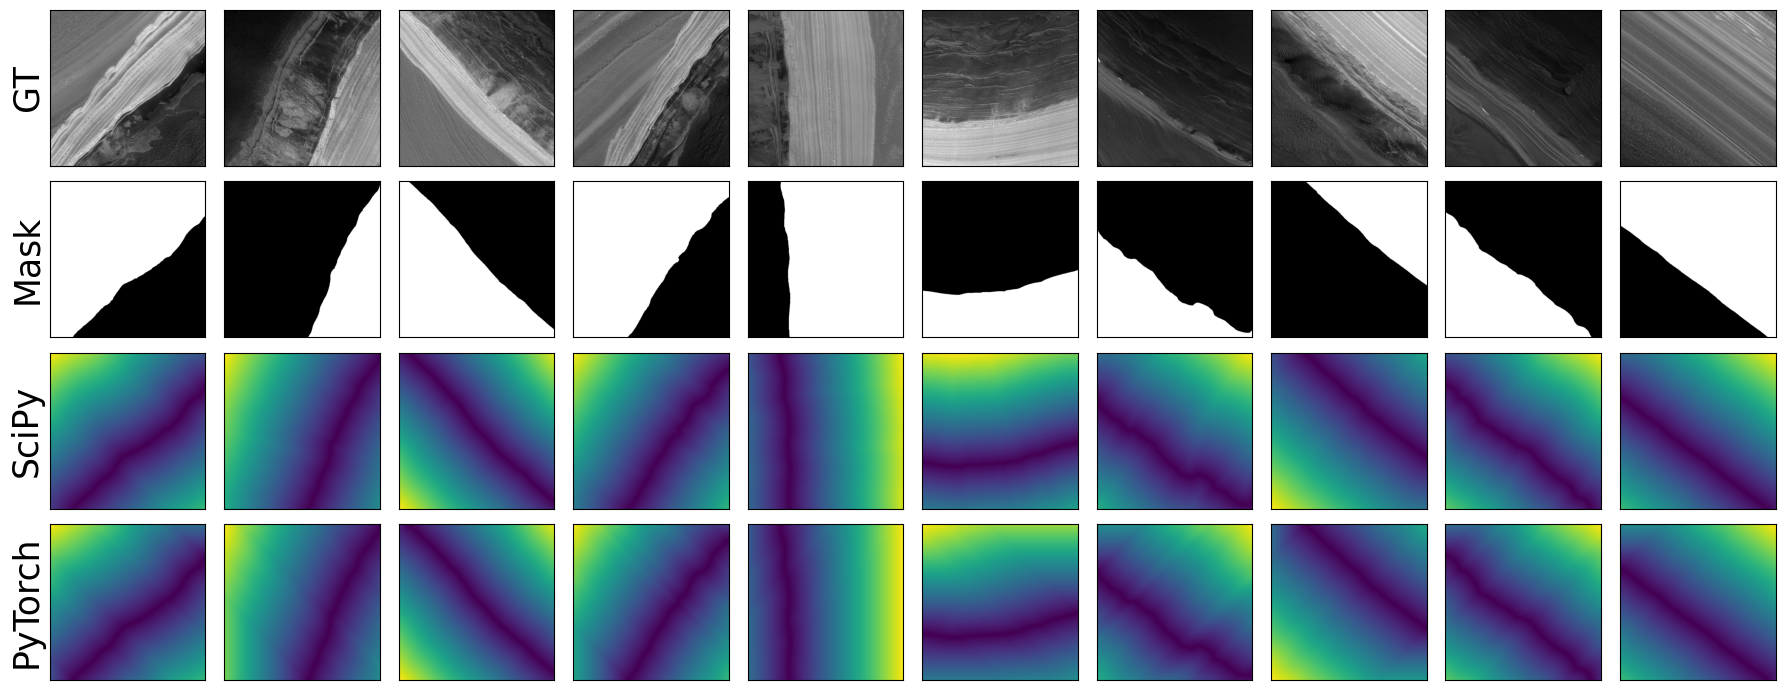

In [37]:
num_imgs = 10
fig, ax = plt.subplots(4, num_imgs, figsize=(18,7))

def plot_smds(fig, ax, imIDs):

    imIDs = np.random.choice(imIDs, num_imgs)
    for i,imID in enumerate(tqdm(imIDs)):
        mask = cv2.imread(f'{CONF.MSK_DIR}/{imID}.png', cv2.IMREAD_GRAYSCALE)
        img = cv2.imread(f'{CONF.IMG_DIR}/{imID}.png', cv2.IMREAD_GRAYSCALE)/255
        edges = cv2.Canny((255*mask).astype(np.uint8), threshold1=128, threshold2=128)
        
        mask_tensor = torch.tensor(mask).to(torch.float32).unsqueeze(0).unsqueeze(0).to('cuda:0')
        
        sdm_scipy = distance_transform_edt(~edges)
        sdm_scipy = sdm_scipy/sdm_scipy.max()

        sdm_torch = SDF.sdf(mask_tensor, K = 7, normalization = None)
        sdm_torch = sdm_torch[0][0].detach().cpu().numpy()
        sdm_torch = sdm_torch/sdm_torch.max()

        ax1, ax2, ax3, ax4 = ax[0], ax[1], ax[2], ax[3]

        ax1[i].imshow(img, cmap = 'gray')
        ax1[i].set_xticks([])
        ax1[i].set_yticks([])

        ax2[i].imshow(mask, cmap = 'gray')
        ax2[i].set_xticks([])
        ax2[i].set_yticks([])

        ax3[i].imshow(sdm_scipy, cmap = 'viridis')
        ax3[i].set_xticks([])
        ax3[i].set_yticks([])
        
        ax4[i].imshow(sdm_torch, cmap = 'viridis')
        ax4[i].set_xticks([])
        ax4[i].set_yticks([])
        

    ax1[0].set_ylabel('GT', fontsize = 25)
    ax2[0].set_ylabel('Mask', fontsize = 25)
    ax3[0].set_ylabel('SciPy', fontsize = 25)
    ax4[0].set_ylabel('PyTorch', fontsize = 25)

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.1)
    

plot_smds(fig, ax, imIDs)
fig.savefig("C:/Users/Oleksii/Desktop/pHD/Thesis/Figures/sdm_results/visual_comparison.png", bbox_inches='tight', dpi=300)